# CFR / CFR+ on Kuhn Poker


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Load Kuhn Poker

In [2]:
from kuhn_poker import KuhnPoker

efg = KuhnPoker.efg()
tfsdp0 = KuhnPoker.tfsdp(player=0)
tfsdp1 = KuhnPoker.tfsdp(player=1)

# efg[""]
# tfsdp0["J"]
# tfsdp0["rho"]

In [3]:
from counter_factual_regret import CounterFactualRegret
from util import expected_value, exploitability, linear_utility


def train(
    steps: int = 20000,
    plus: bool = False,
) -> tuple[dict, dict, float, np.ndarray]:
    cfr0 = CounterFactualRegret(tfsdp0, plus=plus)
    cfr1 = CounterFactualRegret(tfsdp1, plus=plus)
    expl_hist = np.zeros(steps)

    for t in range(steps):
        x0 = cfr0.next_strategy()
        x1 = cfr1.next_strategy()

        l0 = linear_utility(efg, tfsdp0, player=0, opponent_x=x1)
        l1 = linear_utility(efg, tfsdp1, player=1, opponent_x=x0)

        cfr0.observe_utility(l0)
        cfr1.observe_utility(l1)

        x0 = cfr0.average_strategy()
        x1 = cfr1.average_strategy()
        expl_hist[t] = exploitability(efg, tfsdp0, tfsdp1, x0, x1)

    final_ev = expected_value(efg, tfsdp0, tfsdp1, x0, x1, player=0)
    return x0, x1, final_ev, expl_hist

CFR
P0 avg strategy: {'J': {'check': 0.7922, 'bet': 0.2078}, 'Q': {'check': 0.9997, 'bet': 0.0003}, 'K': {'check': 0.3874, 'bet': 0.6126}, 'J|check-bet': {'call': 0.0, 'fold': 1.0}, 'Q|check-bet': {'call': 0.5509, 'fold': 0.4491}, 'K|check-bet': {'call': 1.0, 'fold': 0.0}}
P1 avg strategy: {'J|check': {'check': 0.6655, 'bet': 0.3345}, 'Q|check': {'check': 0.9996, 'bet': 0.0004}, 'K|check': {'check': 0.0001, 'bet': 1.0}, 'J|bet': {'call': 0.0001, 'fold': 1.0}, 'Q|bet': {'call': 0.3393, 'fold': 0.6607}, 'K|bet': {'call': 1.0, 'fold': 0.0001}}
Final EV (P0): -0.055548
Final exploitability: 0.00232917

CFR+
P0 avg strategy: {'J': {'check': 0.7603, 'bet': 0.2397}, 'Q': {'check': 0.9998, 'bet': 0.0002}, 'K': {'check': 0.2804, 'bet': 0.7196}, 'J|check-bet': {'call': 0.0001, 'fold': 1.0}, 'Q|check-bet': {'call': 0.5755, 'fold': 0.4245}, 'K|check-bet': {'call': 1.0, 'fold': 0.0001}}
P1 avg strategy: {'J|check': {'check': 0.6662, 'bet': 0.3338}, 'Q|check': {'check': 0.9997, 'bet': 0.0003}, 'K|ch

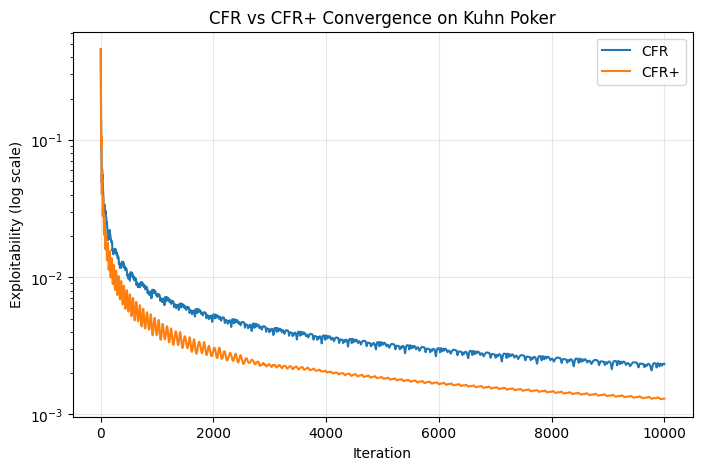

In [4]:
from util import format_strategy

steps = 10000
histories = {}

for plus in [False, True]:
    name = "CFR+" if plus else "CFR"
    x0, x1, final_ev, expl_hist = train(
        steps=steps,
        plus=plus,
    )
    histories[name] = expl_hist
    print(name)
    print("P0 avg strategy:", format_strategy(x0, tfsdp0))
    print("P1 avg strategy:", format_strategy(x1, tfsdp1))
    print("Final EV (P0):", round(float(final_ev), 6))
    print("Final exploitability:", f"{expl_hist[-1]:.8f}")
    print()

iters = np.arange(1, steps + 1)
eps = 1e-12

plt.figure(figsize=(8, 5))
for name in ["CFR", "CFR+"]:
    plt.plot(iters, np.maximum(histories[name], eps), label=name)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Exploitability (log scale)")
plt.title("CFR vs CFR+ Convergence on Kuhn Poker")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()